In [1]:
# ============================================================
# PRODUCT FEEDBACK INTELLIGENCE
# Google Play Review Sentiment Analysis
# ============================================================

# Install required libraries
!pip -q install wordcloud openpyxl

# -----------------------------
# Standard libraries
# -----------------------------
import os
import re
import warnings
import numpy as np
import pandas as pd

# -----------------------------
# Visualization
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# NLP
# -----------------------------
import nltk

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# -----------------------------
# Machine Learning
# -----------------------------
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# -----------------------------
# Word cloud
# -----------------------------
from wordcloud import WordCloud

# -----------------------------
# Display
# -----------------------------
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# Download NLTK resources
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
# ============================================================
# DATASET UPLOAD
# ============================================================

from google.colab import files

print("Please upload your Google Play reviews CSV file.")

uploaded = files.upload()

# Get uploaded filename
file_name = list(uploaded.keys())[0]

print("\nUploaded file:")
print(file_name)

# Read CSV
df = pd.read_csv(file_name)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Please upload your Google Play reviews CSV file.


Saving googleplaystore_user_reviews.csv to googleplaystore_user_reviews.csv

Uploaded file:
googleplaystore_user_reviews.csv

Dataset loaded successfully!
Shape: (64295, 5)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [3]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
for col in df.columns:
    print("-", col)

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nFirst 10 rows:")
display(df.head(10))

DATASET OVERVIEW

Rows: 64295
Columns: 5

Columns:
- App
- Translated_Review
- Sentiment
- Sentiment_Polarity
- Sentiment_Subjectivity

Data types:


,Data Type
App,object
Translated_Review,object
Sentiment,object
Sentiment_Polarity,float64
Sentiment_Subjectivity,float64



First 10 rows:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000
6,10 Best Foods for You,Amazing,Positive,0.60,0.900000
7,10 Best Foods for You,NaN,NaN,NaN,NaN
8,10 Best Foods for You,"Looking forward app,",Neutral,0.00,0.000000
9,10 Best Foods for You,It helpful site ! It help foods get !,Neutral,0.00,0.000000


In [4]:
# ============================================================
# DATA QUALITY ANALYSIS
# ============================================================

print("=" * 70)
print("DATA QUALITY ANALYSIS")
print("=" * 70)

quality = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(2).values,
    "Unique Values": df.nunique().values
})

display(quality)

DATA QUALITY ANALYSIS


,Column,Data Type,Missing Values,Missing %,Unique Values
0,App,object,0,0.00,1074
1,Translated_Review,object,26868,41.79,27994
2,Sentiment,object,26863,41.78,3
3,Sentiment_Polarity,float64,26863,41.78,5410
4,Sentiment_Subjectivity,float64,26863,41.78,4474


In [5]:
# ============================================================
# DUPLICATE ANALYSIS
# ============================================================

print("=" * 70)
print("DUPLICATE ANALYSIS")
print("=" * 70)

exact_duplicates = df.duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)

print(
    "Duplicate review texts:",
    df["Translated_Review"].duplicated().sum()
)

print(
    "Unique applications:",
    df["App"].nunique()
)

DUPLICATE ANALYSIS
Exact duplicate rows: 33616
Duplicate review texts: 36300
Unique applications: 1074


In [6]:
# ============================================================
# CREATE CLEAN LABELLED DATASET
# ============================================================

model_df = df.dropna(
    subset=["Translated_Review", "Sentiment"]
).copy()

print("Original rows:", len(df))
print("Rows with valid review + sentiment:", len(model_df))
print("Rows removed:", len(df) - len(model_df))

# Remove exact duplicate rows
before_duplicates = len(model_df)

model_df = model_df.drop_duplicates().reset_index(drop=True)

after_duplicates = len(model_df)

print("\nExact duplicates removed:",
      before_duplicates - after_duplicates)

print("Final modelling dataset:", len(model_df))

display(model_df.head())

Original rows: 64295
Rows with valid review + sentiment: 37427
Rows removed: 26868

Exact duplicates removed: 7735
Final modelling dataset: 29692


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
3,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
4,10 Best Foods for You,Best way,Positive,1.00,0.300000


In [7]:
# ============================================================
# SENTIMENT DISTRIBUTION
# ============================================================

sentiment_counts = (
    model_df["Sentiment"]
    .value_counts()
    .sort_values(ascending=False)
)

sentiment_percentage = (
    model_df["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment_summary = pd.DataFrame({
    "Reviews": sentiment_counts,
    "Percentage": sentiment_percentage
})

display(sentiment_summary)

,Reviews,Percentage
Sentiment,,
Positive,19015,64.04
Negative,6321,21.29
Neutral,4356,14.67


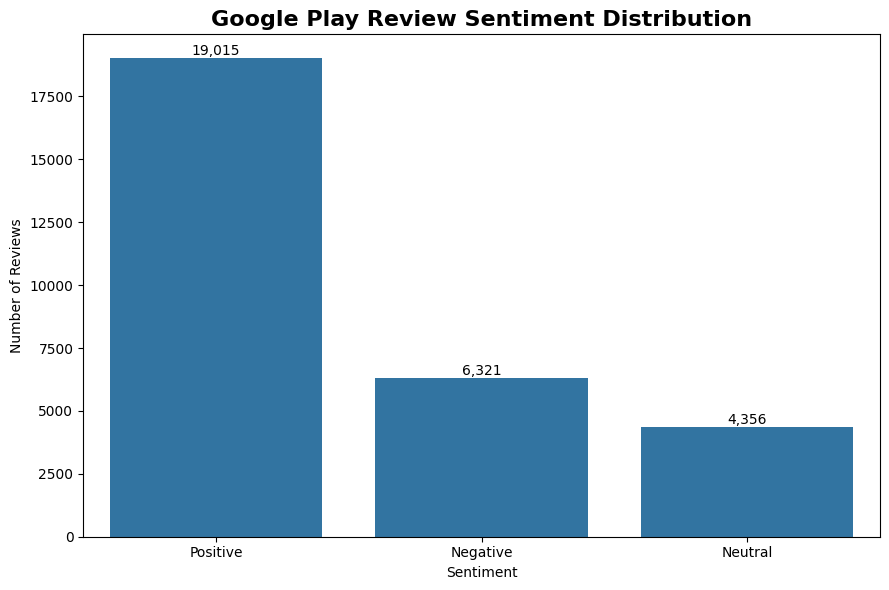

In [8]:
# ============================================================
# SENTIMENT DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title(
    "Google Play Review Sentiment Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for i, value in enumerate(sentiment_counts.values):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# APP-LEVEL ANALYSIS
# ============================================================

app_summary = (
    model_df
    .groupby("App")
    .agg(
        Review_Count=("Translated_Review", "count"),
        Positive=("Sentiment", lambda x: (x == "Positive").sum()),
        Neutral=("Sentiment", lambda x: (x == "Neutral").sum()),
        Negative=("Sentiment", lambda x: (x == "Negative").sum())
    )
    .reset_index()
)

# Calculate percentages
app_summary["Positive_%"] = (
    app_summary["Positive"] /
    app_summary["Review_Count"] * 100
)

app_summary["Neutral_%"] = (
    app_summary["Neutral"] /
    app_summary["Review_Count"] * 100
)

app_summary["Negative_%"] = (
    app_summary["Negative"] /
    app_summary["Review_Count"] * 100
)

app_summary = app_summary.sort_values(
    "Review_Count",
    ascending=False
)

display(app_summary.head(20))

,App,Review_Count,Positive,Neutral,Negative,Positive_%,Neutral_%,Negative_%
571,Facebook,130,53,18,59,40.769231,13.846154,45.384615
536,Episode - Choose Your Story,124,74,13,37,59.677419,10.483871,29.838710
114,Angry Birds Classic,107,47,1,59,43.925234,0.934579,55.140187
583,Family Locator - GPS Tracker,105,85,13,7,80.952381,12.380952,6.666667
754,Google Photos,101,76,1,24,75.247525,0.990099,23.762376
327,Calorie Counter - Macros,100,87,3,10,87.000000,3.000000,10.000000
24,8fit Workouts & Meal Planner,100,82,7,11,82.000000,7.000000,11.000000
328,Calorie Counter - MyFitnessPal,99,66,17,16,66.666667,17.171717,16.161616
378,ColorNote Notepad Notes,99,91,2,6,91.919192,2.020202,6.060606
65,Adobe Acrobat Reader,98,67,11,20,68.367347,11.224490,20.408163


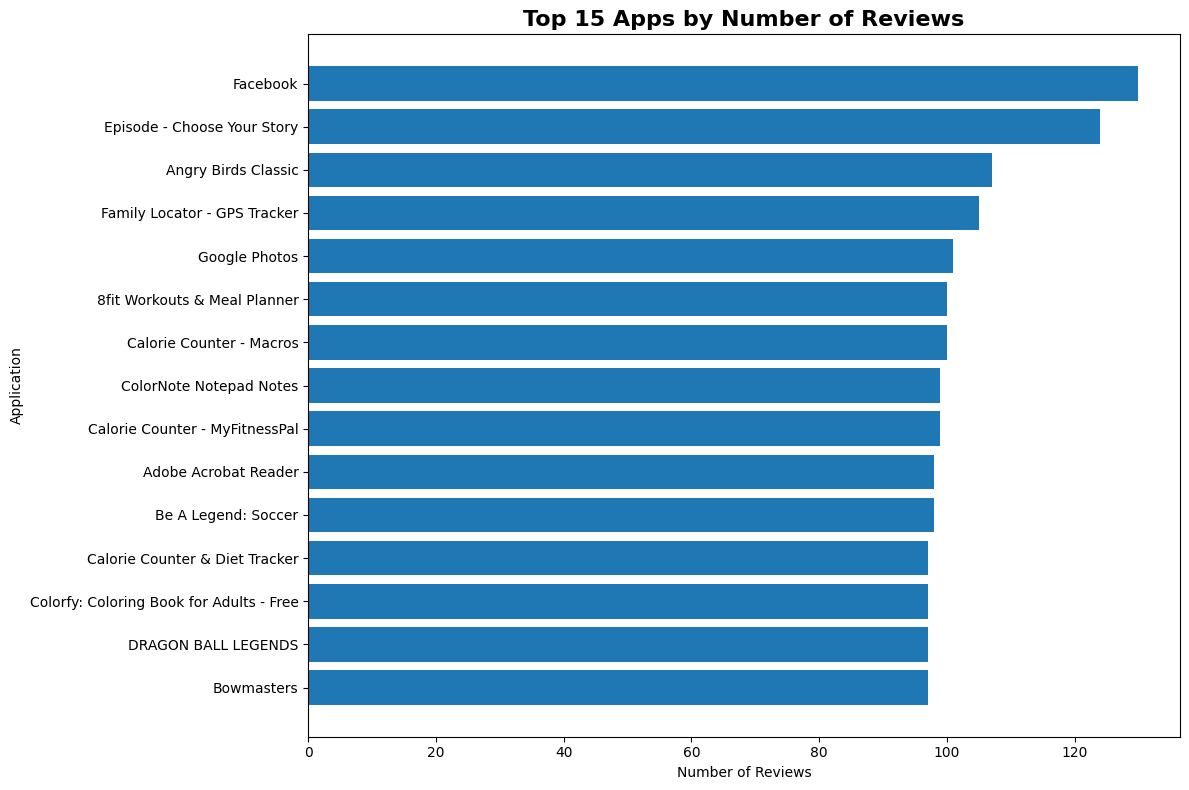

In [10]:
# ============================================================
# TOP APPS BY REVIEW VOLUME
# ============================================================

top_apps = (
    app_summary
    .head(15)
    .sort_values("Review_Count")
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_apps["App"],
    top_apps["Review_Count"]
)

plt.title(
    "Top 15 Apps by Number of Reviews",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Reviews")
plt.ylabel("Application")

plt.tight_layout()
plt.show()

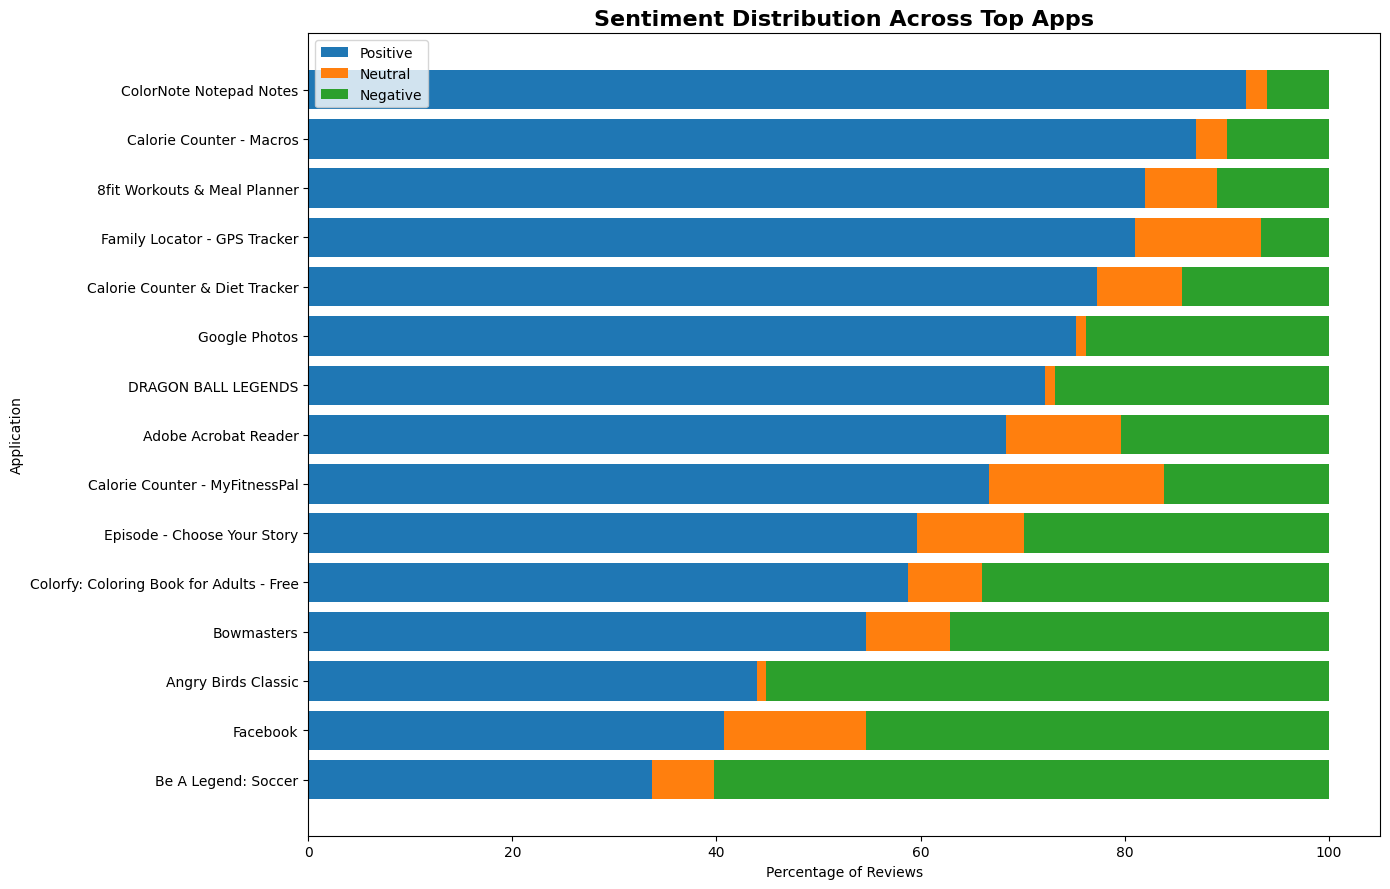

In [11]:
# ============================================================
# SENTIMENT BY TOP APPS
# ============================================================

plot_df = app_summary.head(15).copy()

plot_df = plot_df.sort_values(
    "Positive_%",
    ascending=True
)

plt.figure(figsize=(14, 9))

plt.barh(
    plot_df["App"],
    plot_df["Positive_%"],
    label="Positive"
)

plt.barh(
    plot_df["App"],
    plot_df["Neutral_%"],
    left=plot_df["Positive_%"],
    label="Neutral"
)

plt.barh(
    plot_df["App"],
    plot_df["Negative_%"],
    left=(
        plot_df["Positive_%"] +
        plot_df["Neutral_%"]
    ),
    label="Negative"
)

plt.xlabel("Percentage of Reviews")
plt.ylabel("Application")

plt.title(
    "Sentiment Distribution Across Top Apps",
    fontsize=16,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# REVIEW LENGTH
# ============================================================

model_df["Review_Length"] = (
    model_df["Translated_Review"]
    .astype(str)
    .str.len()
)

model_df["Word_Count"] = (
    model_df["Translated_Review"]
    .astype(str)
    .str.split()
    .str.len()
)

display(
    model_df[
        [
            "Translated_Review",
            "Review_Length",
            "Word_Count",
            "Sentiment"
        ]
    ].head(10)
)

,Translated_Review,Review_Length,Word_Count,Sentiment
0,I like eat delicious food. That's I'm cooking ...,122,21,Positive
1,This help eating healthy exercise regular basis,47,7,Positive
2,Works great especially going grocery store,42,6,Positive
3,Best idea us,12,3,Positive
4,Best way,8,2,Positive
5,Amazing,7,1,Positive
6,"Looking forward app,",20,3,Neutral
7,It helpful site ! It help foods get !,37,9,Neutral
8,good you.,9,2,Positive
9,Useful information The amount spelling errors ...,111,15,Positive


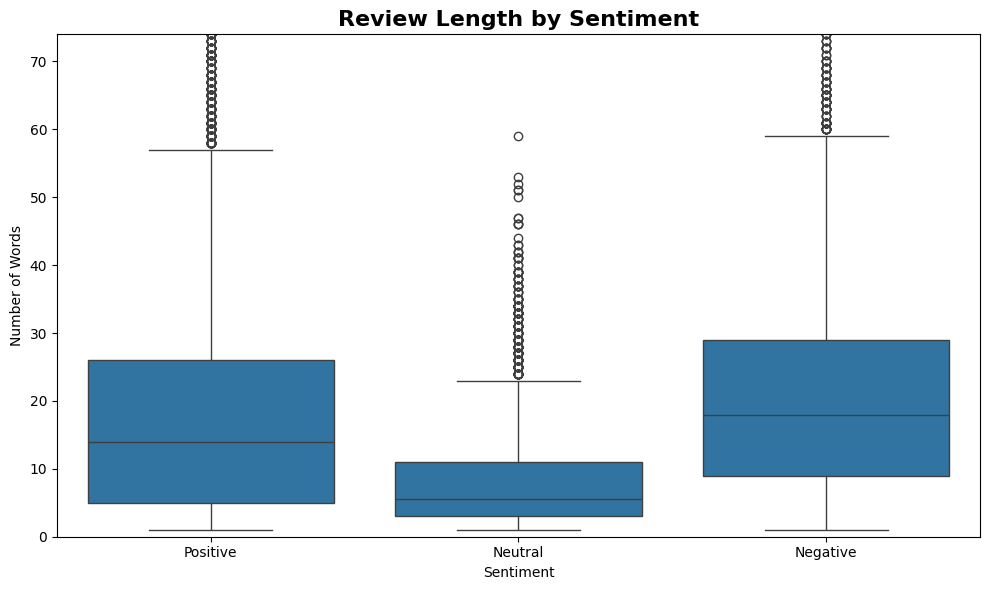

In [13]:
# ============================================================
# REVIEW LENGTH BY SENTIMENT
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=model_df,
    x="Sentiment",
    y="Word_Count"
)

plt.ylim(0, model_df["Word_Count"].quantile(0.99))

plt.title(
    "Review Length by Sentiment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Words")

plt.tight_layout()
plt.show()

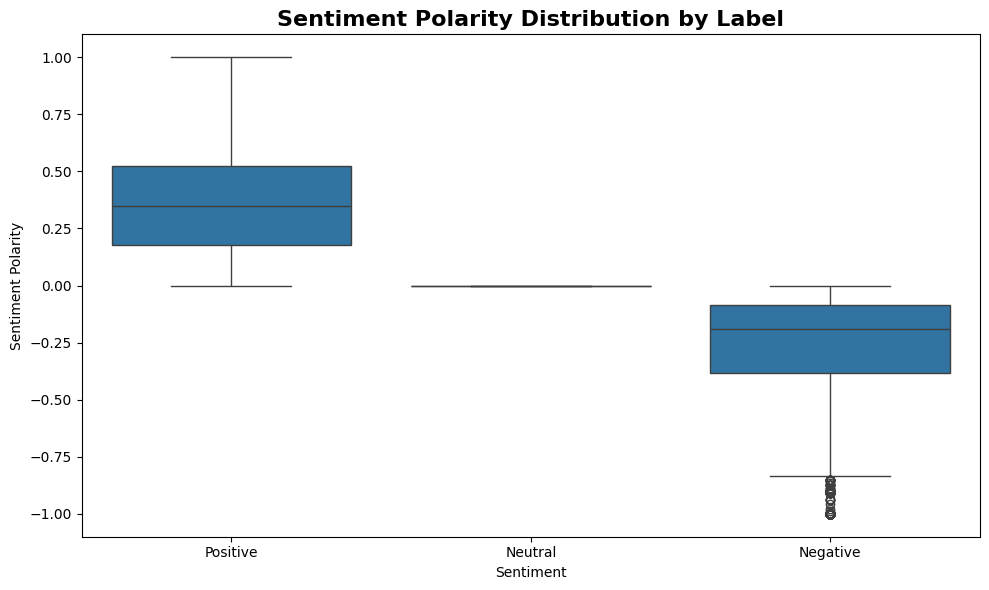

In [14]:
# ============================================================
# POLARITY ANALYSIS
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=model_df,
    x="Sentiment",
    y="Sentiment_Polarity"
)

plt.title(
    "Sentiment Polarity Distribution by Label",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sentiment")
plt.ylabel("Sentiment Polarity")

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# NLP PREPROCESSING
# ============================================================

stop_words = set(stopwords.words("english"))

stemmer = SnowballStemmer("english")


def clean_text(text):
    """
    Clean and normalize review text.
    """

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Keep alphabetic characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenize
    tokens = text.split()

    # Stopword removal
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Stemming
    tokens = [
        stemmer.stem(word)
        for word in tokens
    ]

    return " ".join(tokens)


print("Testing preprocessing:")

sample_reviews = model_df["Translated_Review"].head(5)

for review in sample_reviews:

    print("\nOriginal:")
    print(review)

    print("\nProcessed:")
    print(clean_text(review))

    print("-" * 70)

Testing preprocessing:

Original:
I like eat delicious food. That's I'm cooking food myself, case "10 Best Foods" helps lot, also "Best Before (Shelf Life)"

Processed:
like eat delici food cook food case best food help lot also best shelf life
----------------------------------------------------------------------

Original:
This help eating healthy exercise regular basis

Processed:
help eat healthi exercis regular basi
----------------------------------------------------------------------

Original:
Works great especially going grocery store

Processed:
work great especi go groceri store
----------------------------------------------------------------------

Original:
Best idea us

Processed:
best idea us
----------------------------------------------------------------------

Original:
Best way

Processed:
best way
----------------------------------------------------------------------


In [16]:
# ============================================================
# APPLY TEXT PREPROCESSING
# ============================================================

print("Cleaning reviews...")

model_df["Clean_Review"] = (
    model_df["Translated_Review"]
    .apply(clean_text)
)

print("Cleaning completed.")

display(
    model_df[
        [
            "Translated_Review",
            "Clean_Review",
            "Sentiment"
        ]
    ].head(10)
)

Cleaning reviews...
Cleaning completed.


,Translated_Review,Clean_Review,Sentiment
0,I like eat delicious food. That's I'm cooking ...,like eat delici food cook food case best food ...,Positive
1,This help eating healthy exercise regular basis,help eat healthi exercis regular basi,Positive
2,Works great especially going grocery store,work great especi go groceri store,Positive
3,Best idea us,best idea us,Positive
4,Best way,best way,Positive
5,Amazing,amaz,Positive
6,"Looking forward app,",look forward app,Neutral
7,It helpful site ! It help foods get !,help site help food get,Neutral
8,good you.,good,Positive
9,Useful information The amount spelling errors ...,use inform amount spell error question valid i...,Positive


In [17]:
# ============================================================
# REMOVE EMPTY PROCESSED REVIEWS
# ============================================================

before = len(model_df)

model_df = model_df[
    model_df["Clean_Review"].str.strip().ne("")
].copy()

model_df.reset_index(drop=True, inplace=True)

after = len(model_df)

print("Rows before:", before)
print("Rows after:", after)
print("Empty processed reviews removed:", before - after)

Rows before: 29692
Rows after: 29638
Empty processed reviews removed: 54


In [18]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X = model_df["Clean_Review"]

y = model_df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

print("\nTraining sentiment distribution:")
display(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting sentiment distribution:")
display(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training reviews: 23710
Testing reviews: 5928

Training sentiment distribution:


,proportion
Sentiment,
Positive,64.15
Negative,21.33
Neutral,14.53



Testing sentiment distribution:


,proportion
Sentiment,
Positive,64.15
Negative,21.32
Neutral,14.52


In [19]:
# ============================================================
# TF-IDF FEATURE ENGINEERING
# ============================================================

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF created successfully.")

print("\nTraining matrix shape:")
print(X_train_tfidf.shape)

print("\nTesting matrix shape:")
print(X_test_tfidf.shape)

print("\nNumber of vocabulary features:")
print(len(tfidf.get_feature_names_out()))

TF-IDF created successfully.

Training matrix shape:
(23710, 20000)

Testing matrix shape:
(5928, 20000)

Number of vocabulary features:
20000


In [20]:
# ============================================================
# MODEL 1 — LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(
    max_iter=2000,
    C=1.0,
    class_weight=None,
    random_state=42
)

print("Training Logistic Regression...")

logistic_model.fit(
    X_train_tfidf,
    y_train
)

print("Training completed.")

lr_predictions = logistic_model.predict(
    X_test_tfidf
)

Training Logistic Regression...
Training completed.


In [21]:
# ============================================================
# LOGISTIC REGRESSION EVALUATION
# ============================================================

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

lr_precision = precision_score(
    y_test,
    lr_predictions,
    average="macro"
)

lr_recall = recall_score(
    y_test,
    lr_predictions,
    average="macro"
)

lr_f1 = f1_score(
    y_test,
    lr_predictions,
    average="macro"
)

print("=" * 70)
print("LOGISTIC REGRESSION")
print("=" * 70)

print(f"Accuracy        : {lr_accuracy:.4f}")
print(f"Macro Precision : {lr_precision:.4f}")
print(f"Macro Recall    : {lr_recall:.4f}")
print(f"Macro F1        : {lr_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        lr_predictions
    )
)

LOGISTIC REGRESSION
Accuracy        : 0.8637
Macro Precision : 0.8568
Macro Recall    : 0.7821
Macro F1        : 0.8133

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.69      0.77      1264
     Neutral       0.84      0.69      0.76       861
    Positive       0.87      0.96      0.91      3803

    accuracy                           0.86      5928
   macro avg       0.86      0.78      0.81      5928
weighted avg       0.86      0.86      0.86      5928



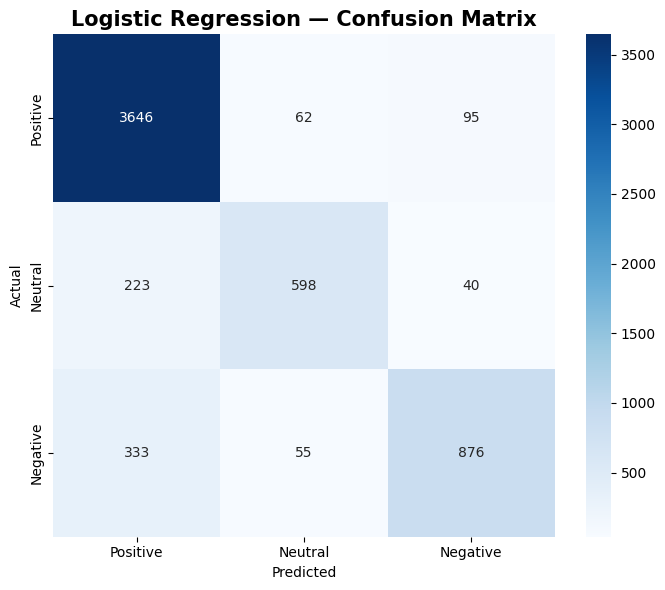

In [22]:
# ============================================================
# LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

labels = ["Positive", "Neutral", "Negative"]

lr_cm = confusion_matrix(
    y_test,
    lr_predictions,
    labels=labels
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Logistic Regression — Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# MODEL 2 — LINEAR SVM
# ============================================================

svm_model = LinearSVC(
    C=1.0,
    class_weight=None,
    random_state=42
)

print("Training Linear SVM...")

svm_model.fit(
    X_train_tfidf,
    y_train
)

print("Training completed.")

svm_predictions = svm_model.predict(
    X_test_tfidf
)

Training Linear SVM...
Training completed.


In [24]:
# ============================================================
# LINEAR SVM EVALUATION
# ============================================================

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    average="macro"
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    average="macro"
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    average="macro"
)

print("=" * 70)
print("LINEAR SVM")
print("=" * 70)

print(f"Accuracy        : {svm_accuracy:.4f}")
print(f"Macro Precision : {svm_precision:.4f}")
print(f"Macro Recall    : {svm_recall:.4f}")
print(f"Macro F1        : {svm_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        svm_predictions
    )
)

LINEAR SVM
Accuracy        : 0.8723
Macro Precision : 0.8457
Macro Recall    : 0.8156
Macro F1        : 0.8294

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.74      0.78      1264
     Neutral       0.81      0.77      0.79       861
    Positive       0.90      0.94      0.92      3803

    accuracy                           0.87      5928
   macro avg       0.85      0.82      0.83      5928
weighted avg       0.87      0.87      0.87      5928



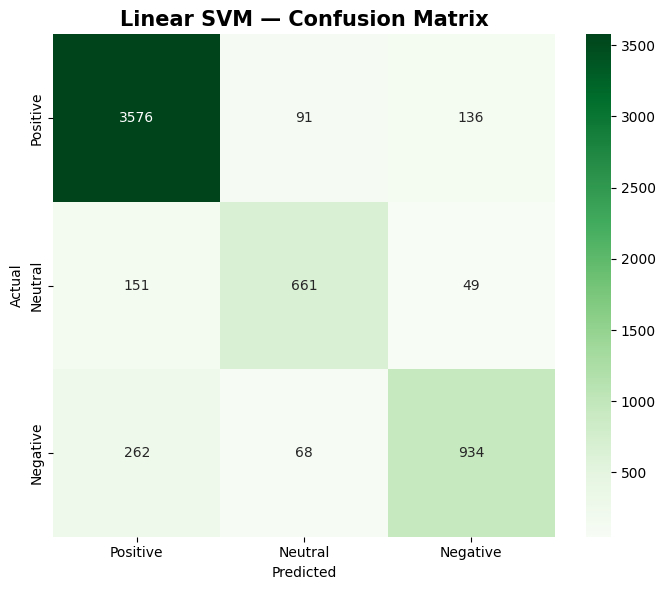

In [25]:
# ============================================================
# SVM CONFUSION MATRIX
# ============================================================

svm_cm = confusion_matrix(
    y_test,
    svm_predictions,
    labels=labels
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Linear SVM — Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# MODEL 3 — MULTINOMIAL NAIVE BAYES
# ============================================================

nb_model = MultinomialNB(
    alpha=1.0
)

print("Training Naive Bayes...")

nb_model.fit(
    X_train_tfidf,
    y_train
)

print("Training completed.")

nb_predictions = nb_model.predict(
    X_test_tfidf
)

Training Naive Bayes...
Training completed.


In [27]:
# ============================================================
# NAIVE BAYES EVALUATION
# ============================================================

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    average="macro"
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    average="macro"
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average="macro"
)

print("=" * 70)
print("NAIVE BAYES")
print("=" * 70)

print(f"Accuracy        : {nb_accuracy:.4f}")
print(f"Macro Precision : {nb_precision:.4f}")
print(f"Macro Recall    : {nb_recall:.4f}")
print(f"Macro F1        : {nb_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        nb_predictions
    )
)

NAIVE BAYES
Accuracy        : 0.6923
Macro Precision : 0.8205
Macro Recall    : 0.4175
Macro F1        : 0.4067

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.24      0.38      1264
     Neutral       0.89      0.02      0.04       861
    Positive       0.68      1.00      0.81      3803

    accuracy                           0.69      5928
   macro avg       0.82      0.42      0.41      5928
weighted avg       0.76      0.69      0.60      5928



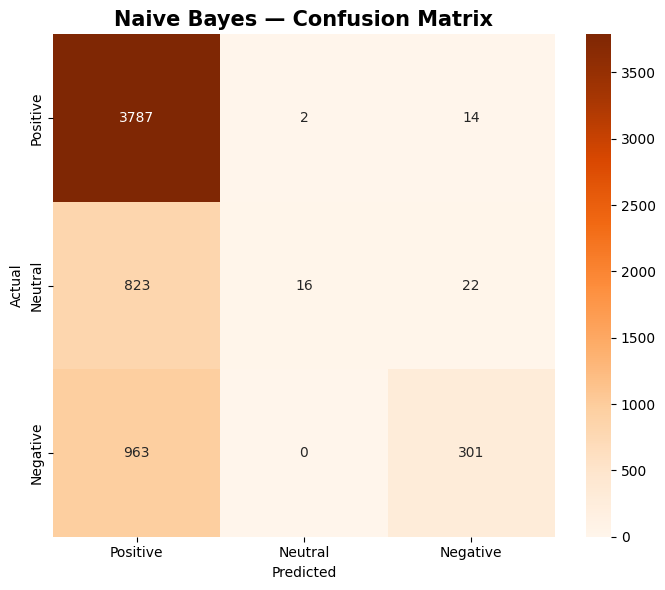

In [28]:
# ============================================================
# NAIVE BAYES CONFUSION MATRIX
# ============================================================

nb_cm = confusion_matrix(
    y_test,
    nb_predictions,
    labels=labels
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Naive Bayes — Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes"
    ],

    "Accuracy": [
        lr_accuracy,
        svm_accuracy,
        nb_accuracy
    ],

    "Macro Precision": [
        lr_precision,
        svm_precision,
        nb_precision
    ],

    "Macro Recall": [
        lr_recall,
        svm_recall,
        nb_recall
    ],

    "Macro F1": [
        lr_f1,
        svm_f1,
        nb_f1
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.8637,0.8568,0.7821,0.8133
1,Linear SVM,0.8723,0.8457,0.8156,0.8294
2,Naive Bayes,0.6923,0.8205,0.4175,0.4067


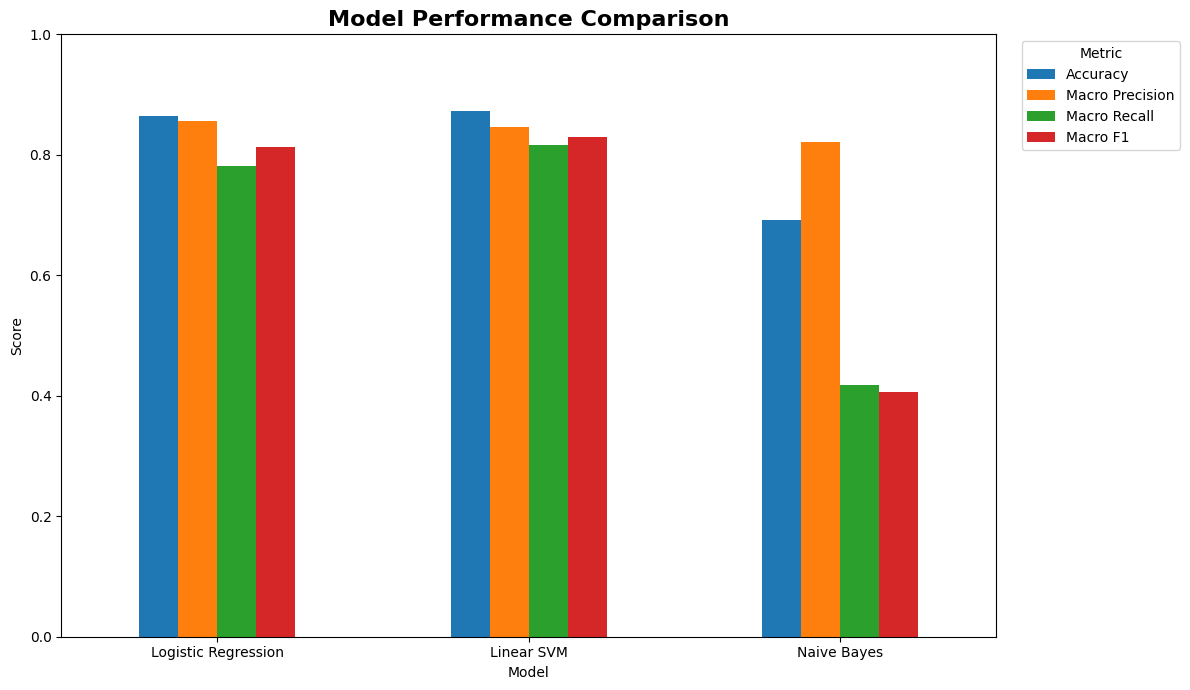

In [30]:
# ============================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================

plot_results = results.set_index("Model")

ax = plot_results.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

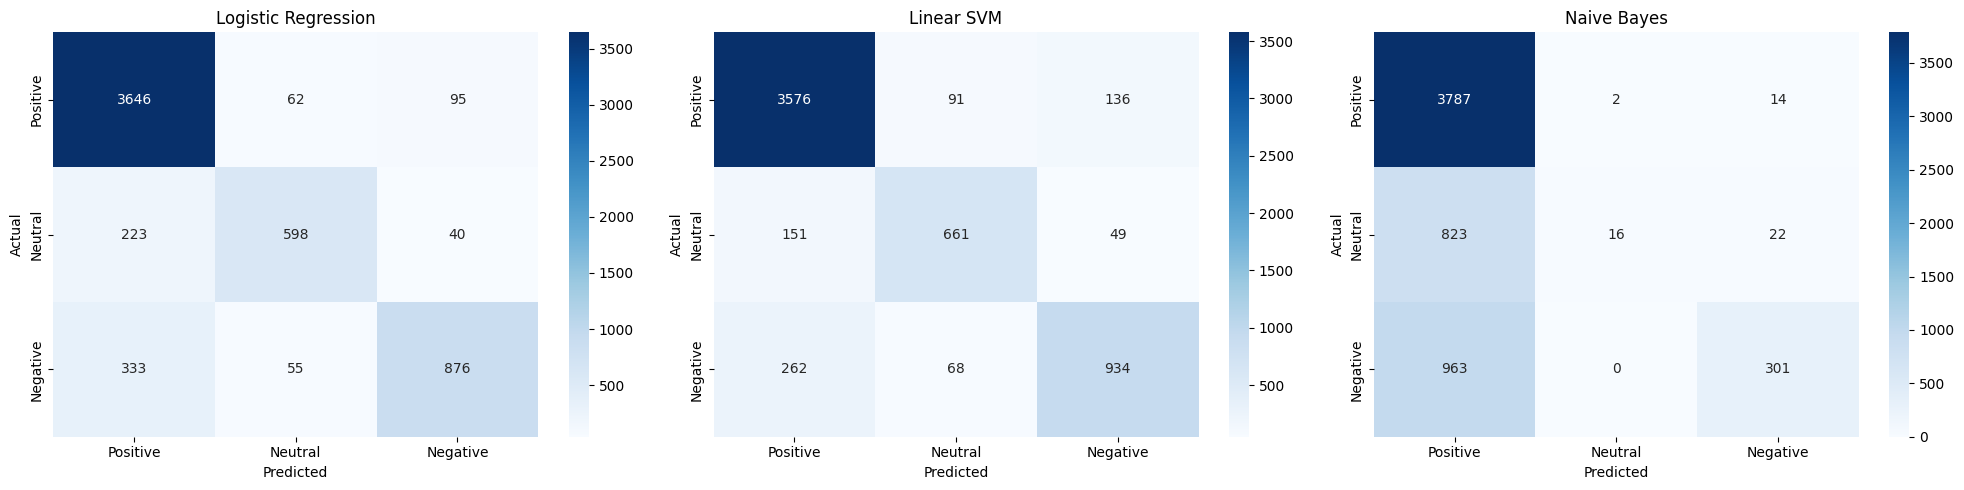

In [31]:
# ============================================================
# CONFUSION MATRIX COMPARISON
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5)
)

matrices = [
    ("Logistic Regression", lr_cm),
    ("Linear SVM", svm_cm),
    ("Naive Bayes", nb_cm)
]

for ax, (name, cm) in zip(axes, matrices):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# CLASS-LEVEL PERFORMANCE
# ============================================================

def get_class_metrics(y_true, y_pred, model_name):

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True
    )

    rows = []

    for sentiment in ["Positive", "Neutral", "Negative"]:

        rows.append({

            "Model": model_name,

            "Sentiment": sentiment,

            "Precision": report[sentiment]["precision"],

            "Recall": report[sentiment]["recall"],

            "F1": report[sentiment]["f1-score"],

            "Support": report[sentiment]["support"]
        })

    return pd.DataFrame(rows)


class_metrics = pd.concat([

    get_class_metrics(
        y_test,
        lr_predictions,
        "Logistic Regression"
    ),

    get_class_metrics(
        y_test,
        svm_predictions,
        "Linear SVM"
    ),

    get_class_metrics(
        y_test,
        nb_predictions,
        "Naive Bayes"
    )

])

display(
    class_metrics.round(4)
)

,Model,Sentiment,Precision,Recall,F1,Support
0,Logistic Regression,Positive,0.8677,0.9587,0.9109,3803.0
1,Logistic Regression,Neutral,0.8364,0.6945,0.7589,861.0
2,Logistic Regression,Negative,0.8665,0.6930,0.7701,1264.0
0,Linear SVM,Positive,0.8965,0.9403,0.9179,3803.0
1,Linear SVM,Neutral,0.8061,0.7677,0.7864,861.0
2,Linear SVM,Negative,0.8347,0.7389,0.7839,1264.0
0,Naive Bayes,Positive,0.6795,0.9958,0.8078,3803.0
1,Naive Bayes,Neutral,0.8889,0.0186,0.0364,861.0
2,Naive Bayes,Negative,0.8932,0.2381,0.3760,1264.0


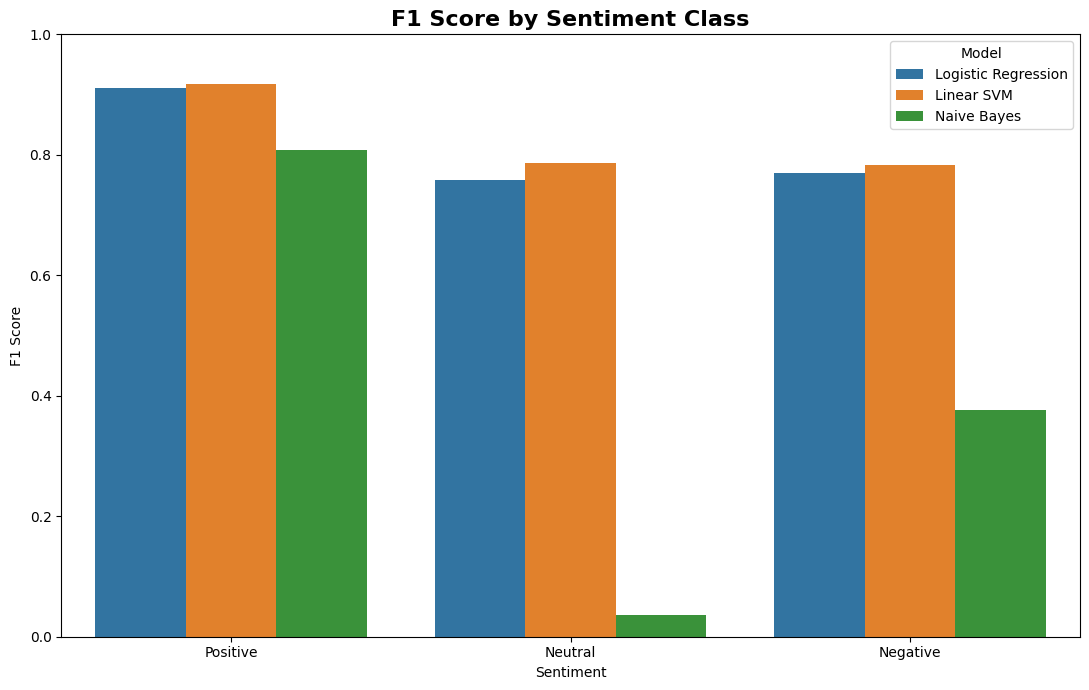

In [33]:
# ============================================================
# CLASS-LEVEL F1 COMPARISON
# ============================================================

plt.figure(figsize=(11, 7))

sns.barplot(
    data=class_metrics,
    x="Sentiment",
    y="F1",
    hue="Model"
)

plt.title(
    "F1 Score by Sentiment Class",
    fontsize=16,
    fontweight="bold"
)

plt.ylim(0, 1)

plt.ylabel("F1 Score")
plt.xlabel("Sentiment")

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# ERROR ANALYSIS — SVM
# ============================================================

error_analysis = model_df.loc[
    X_test.index
].copy()

error_analysis["Predicted_Sentiment"] = svm_predictions

error_analysis["Correct"] = (
    error_analysis["Sentiment"] ==
    error_analysis["Predicted_Sentiment"]
)

errors = error_analysis[
    ~error_analysis["Correct"]
].copy()

print("Total test observations:", len(error_analysis))
print("Misclassified observations:", len(errors))

print(
    "Error rate:",
    round(len(errors) / len(error_analysis) * 100, 2),
    "%"
)

display(
    errors[
        [
            "App",
            "Translated_Review",
            "Sentiment",
            "Predicted_Sentiment"
        ]
    ].head(20)
)

Total test observations: 5928
Misclassified observations: 757
Error rate: 12.77 %


,App,Translated_Review,Sentiment,Predicted_Sentiment
22121,Food Network,I cant get programs work cast. Its like tries ...,Negative,Neutral
6661,Barbie™ Fashion Closet,This game better anger stick J5,Negative,Positive
25551,Golfshot Plus: Golf GPS,Coming using iPhone version last couple years ...,Negative,Positive
11286,Candy Crush Soda Saga,Can fun frustrating totally rigged. Most time ...,Positive,Negative
27955,Health and Nutrition Guide,The facts correct I'm seeing anything except f...,Neutral,Positive
3010,Alto's Adventure,"I absolutely love game, night cycle really tak...",Negative,Positive
6869,Basketball FRVR - Shoot the Hoop and Slam Dunk!,Nice game problem game I start game start play...,Negative,Positive
20920,File Explorer,Really well programed Its size small slow mobi...,Negative,Positive
17146,Dropbox,crashes every time I try manually upload image...,Negative,Positive
27170,HTC Mail,New update sucks!! I able send email since!! I...,Positive,Negative


In [35]:
# ============================================================
# ERROR TYPE ANALYSIS
# ============================================================

errors["Error_Type"] = (
    errors["Sentiment"]
    + " → "
    + errors["Predicted_Sentiment"]
)

error_counts = (
    errors["Error_Type"]
    .value_counts()
)

display(
    error_counts.to_frame("Count")
)

,Count
Error_Type,
Negative → Positive,262
Neutral → Positive,151
Positive → Negative,136
Positive → Neutral,91
Negative → Neutral,68
Neutral → Negative,49


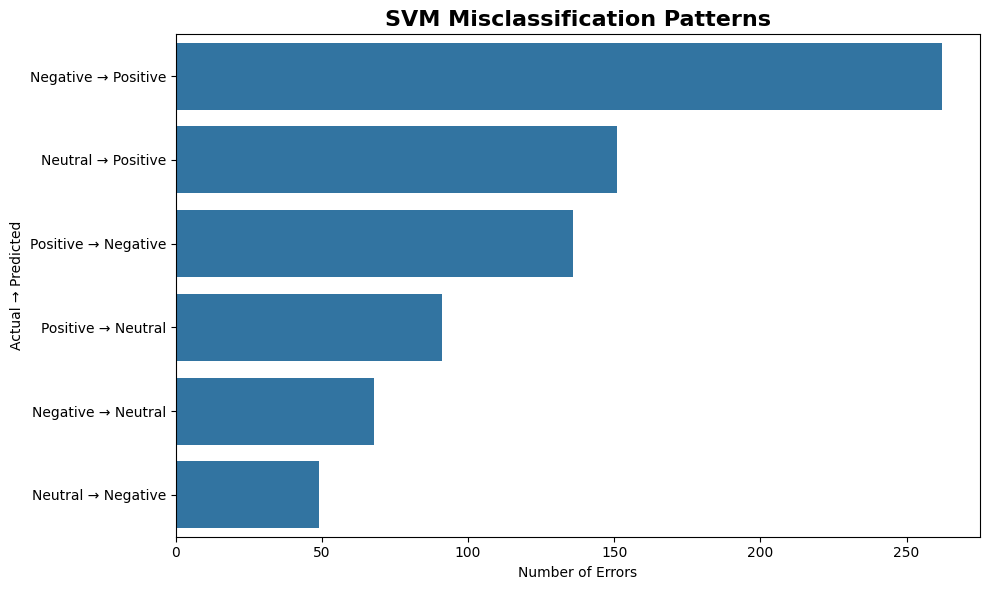

In [36]:
# ============================================================
# ERROR TYPE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x=error_counts.values,
    y=error_counts.index
)

plt.title(
    "SVM Misclassification Patterns",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Errors")
plt.ylabel("Actual → Predicted")

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# SAMPLE MISCLASSIFIED REVIEWS
# ============================================================

pd.set_option(
    "display.max_colwidth",
    200
)

display(
    errors[
        [
            "App",
            "Translated_Review",
            "Sentiment",
            "Predicted_Sentiment"
        ]
    ]
    .sample(
        min(30, len(errors)),
        random_state=42
    )
)

,App,Translated_Review,Sentiment,Predicted_Sentiment
9633,Business Calendar 2,"Up 5 minutes ago problem I widget home screen would delete occasionally. 5 minutes ago, scanning events upcoming weeks widget, every event I manually entered deleted itself. Everything. Edit: I we...",Neutral,Positive
11916,"CheapTickets – Hotels, Flights & Travel Deals","This save itenary, inconvenient trying access travel information.",Negative,Neutral
15425,"Delivery Club–Доставка еды:пицца,суши,бургер,салат","In any modern application should be support for different languages. At least international - English. My wife does not speak Russian, so she can not use the services. In addition, authorization i...",Negative,Positive
12049,Checkers ✔️,It's simple I need somebody tight,Negative,Positive
1728,"AVG Cleaner – Speed, Battery & Memory Booster",It seems working far... My line started cutting reboot. Kept rebooting itself. So I master reset. It still would cut off. So hopefully keeps cutting detect problem.,Negative,Positive
21674,Flights,"Getting vastly different results search website. Painful navigate, way share details.",Negative,Neutral
14658,Cycling - Bike Tracker,Gps fails sometimes final results OK.nice,Negative,Positive
7596,Betterment,Liked,Positive,Neutral
28200,Hello Kitty Nail Salon,I wish I able play without ads. My daughter trouble getting past ads.,Positive,Negative
13802,Cookpad,from those who can't cook at all. just cook eggs. now you can have a lot of it :( huhuhuhu it's bad,Negative,Neutral


In [38]:
# ============================================================
# LOGISTIC REGRESSION FEATURE ANALYSIS
# ============================================================

feature_names = np.array(
    tfidf.get_feature_names_out()
)

classes = logistic_model.classes_

print("Classes:")
print(classes)

Classes:
['Negative' 'Neutral' 'Positive']


In [39]:
# ============================================================
# TOP FEATURES BY SENTIMENT
# ============================================================

for i, sentiment in enumerate(classes):

    coefficients = logistic_model.coef_[i]

    top_indices = np.argsort(coefficients)[-20:][::-1]

    print("\n" + "=" * 70)
    print(f"TOP TERMS ASSOCIATED WITH: {sentiment}")
    print("=" * 70)

    for index in top_indices:
        print(
            f"{feature_names[index]:30s} "
            f"{coefficients[index]:.4f}"
        )


TOP TERMS ASSOCIATED WITH: Negative
game                           7.5476
annoy                          6.9746
worst                          6.2641
hate                           6.2439
terribl                        5.9234
useless                        5.8487
disappoint                     5.6015
horribl                        5.4619
bad                            5.0685
stupid                         5.0025
unabl                          4.5776
wrong                          4.5551
slow                           4.2237
aw                             4.0280
bore                           4.0244
difficult                      3.9982
frustrat                       3.9499
fake                           3.9358
imposs                         3.9277
hard                           3.8312

TOP TERMS ASSOCIATED WITH: Neutral
use time                       1.1412
rubbish                        1.0954
nyc                            0.9265
work                           0.9240
nonsens        

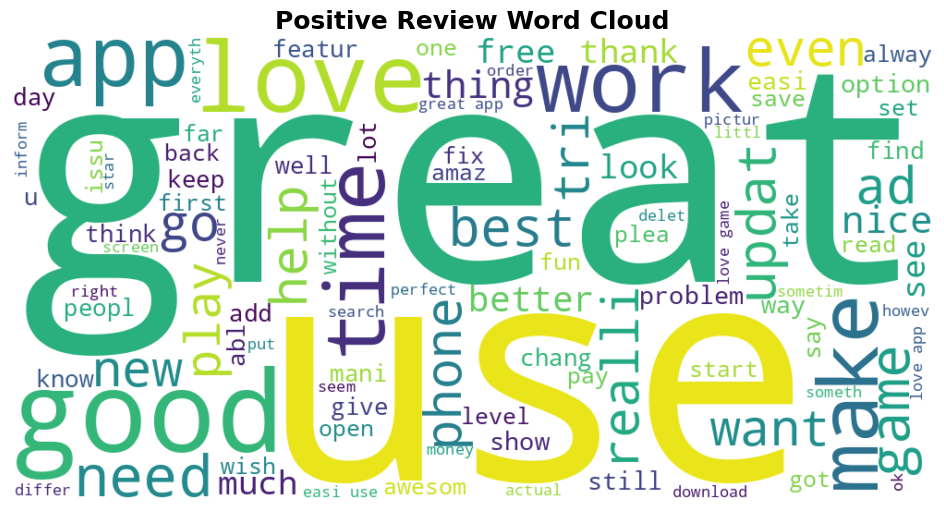

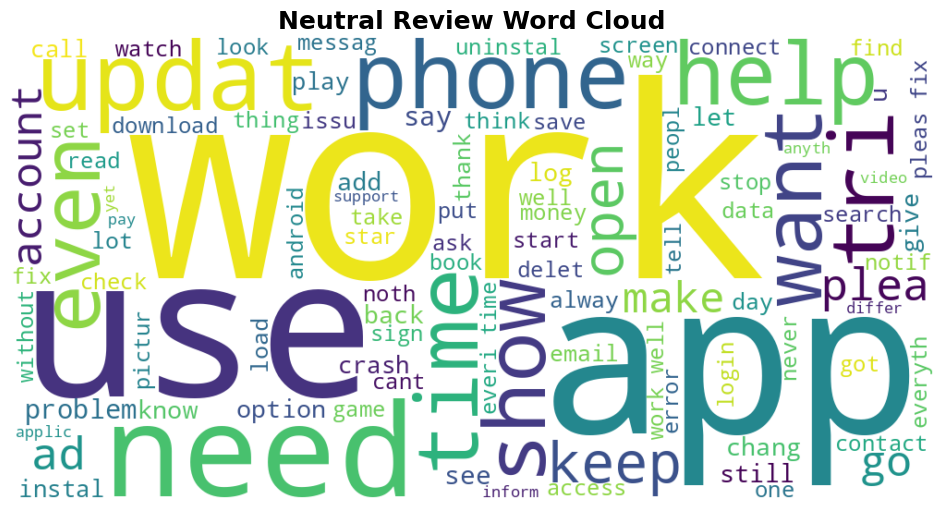

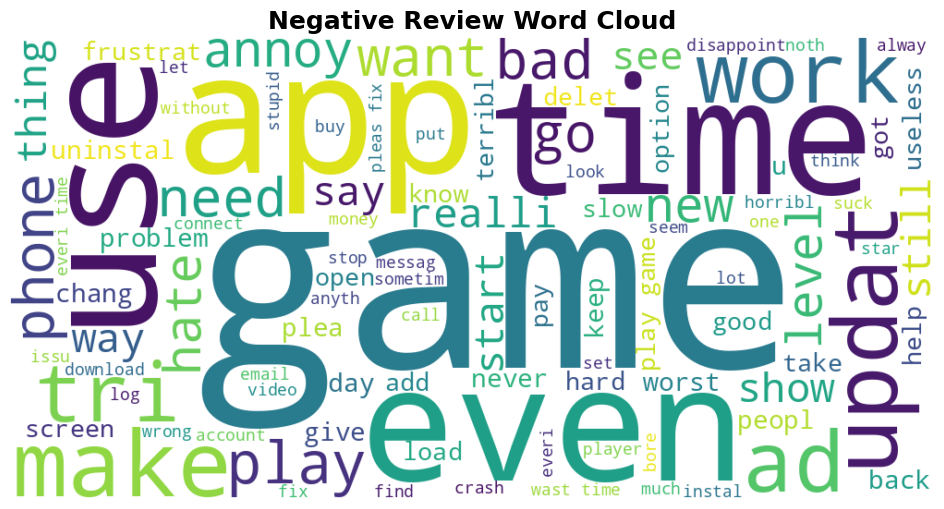

In [40]:
# ============================================================
# WORD CLOUDS BY SENTIMENT
# ============================================================

for sentiment in ["Positive", "Neutral", "Negative"]:

    text = " ".join(
        model_df.loc[
            model_df["Sentiment"] == sentiment,
            "Clean_Review"
        ]
    )

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate(text)

    plt.figure(figsize=(14, 6))

    plt.imshow(
        wordcloud,
        interpolation="bilinear"
    )

    plt.axis("off")

    plt.title(
        f"{sentiment} Review Word Cloud",
        fontsize=18,
        fontweight="bold"
    )

    plt.show()

In [41]:
# ============================================================
# PRODUCT OPPORTUNITY ANALYSIS
# ============================================================

product_analysis = app_summary.copy()

product_analysis["Negative_Risk_Index"] = (
    product_analysis["Negative_%"] *
    np.log1p(product_analysis["Review_Count"])
)

product_analysis = product_analysis.sort_values(
    "Negative_Risk_Index",
    ascending=False
)

display(
    product_analysis[
        [
            "App",
            "Review_Count",
            "Positive_%",
            "Neutral_%",
            "Negative_%",
            "Negative_Risk_Index"
        ]
    ].head(20)
)

,App,Review_Count,Positive_%,Neutral_%,Negative_%,Negative_Risk_Index
209,Be A Legend: Soccer,98,33.673469,6.122449,60.204082,276.644971
395,Cooking Fever,96,39.583333,1.041667,59.375000,271.623464
114,Angry Birds Classic,107,43.925234,0.934579,55.140187,258.173591
335,Candy Crush Soda Saga,91,40.659341,4.395604,54.945055,248.449922
717,Gardenscapes,96,47.916667,0.000000,52.083333,238.266197
774,HBO GO: Stream with TV Package,25,24.000000,8.000000,68.000000,221.550565
571,Facebook,130,40.769231,13.846154,45.384615,221.258955
22,8 Ball Pool,96,50.000000,2.083333,47.916667,219.204901
727,GoPro (formerly Capture),39,38.461538,2.564103,58.974359,217.549301
373,Color Road,37,37.837838,2.702703,59.459459,216.288907


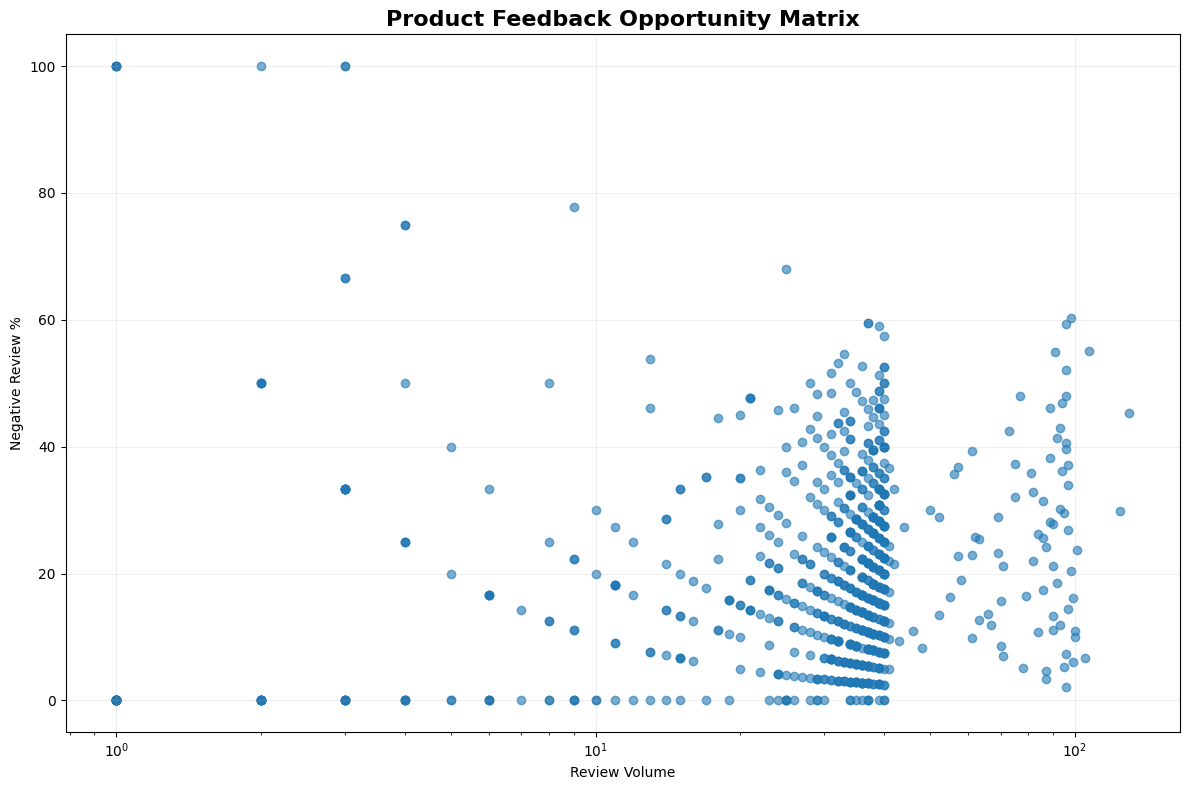

In [42]:
# ============================================================
# PRODUCT OPPORTUNITY MATRIX
# ============================================================

plt.figure(figsize=(12, 8))

plt.scatter(
    product_analysis["Review_Count"],
    product_analysis["Negative_%"],
    alpha=0.6
)

plt.xlabel("Review Volume")
plt.ylabel("Negative Review %")

plt.title(
    "Product Feedback Opportunity Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xscale("log")

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# TOP APPS BY NEGATIVE SENTIMENT
# ============================================================

top_negative_apps = (
    product_analysis[
        product_analysis["Review_Count"] >= 50
    ]
    .sort_values(
        "Negative_%",
        ascending=False
    )
    .head(20)
)

display(
    top_negative_apps[
        [
            "App",
            "Review_Count",
            "Positive_%",
            "Neutral_%",
            "Negative_%"
        ]
    ].round(2)
)

,App,Review_Count,Positive_%,Neutral_%,Negative_%
209,Be A Legend: Soccer,98,33.67,6.12,60.20
395,Cooking Fever,96,39.58,1.04,59.38
114,Angry Birds Classic,107,43.93,0.93,55.14
335,Candy Crush Soda Saga,91,40.66,4.40,54.95
717,Gardenscapes,96,47.92,0.00,52.08
185,Bad Piggies,77,48.05,3.90,48.05
22,8 Ball Pool,96,50.00,2.08,47.92
68,Agar.io,94,44.68,8.51,46.81
206,Basketball Stars,89,49.44,4.49,46.07
571,Facebook,130,40.77,13.85,45.38


In [44]:
# ============================================================
# EXECUTIVE SUMMARY
# ============================================================

best_f1_model = (
    results
    .sort_values(
        "Macro F1",
        ascending=False
    )
    .iloc[0]
)

highest_accuracy_model = (
    results
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .iloc[0]
)

print("=" * 80)
print("PRODUCT FEEDBACK INTELLIGENCE — EXECUTIVE SUMMARY")
print("=" * 80)

print(f"""
Dataset
-------
Total raw records: {len(df):,}
Usable labelled reviews: {len(model_df):,}
Unique applications: {model_df['App'].nunique():,}

Sentiment Distribution
----------------------
Positive: {(model_df['Sentiment'] == 'Positive').sum():,}
Neutral : {(model_df['Sentiment'] == 'Neutral').sum():,}
Negative: {(model_df['Sentiment'] == 'Negative').sum():,}

Model Evaluation
----------------
Highest observed accuracy:
{highest_accuracy_model['Model']}
Accuracy = {highest_accuracy_model['Accuracy']:.4f}

Highest observed Macro F1:
{best_f1_model['Model']}
Macro F1 = {best_f1_model['Macro F1']:.4f}

Business Interpretation
-----------------------
The analysis converts customer reviews into structured sentiment
signals that can be used to identify patterns across applications,
compare model behaviour, and prioritize reviews/apps for deeper
product investigation.

Important:
Model performance should be interpreted using multiple metrics,
especially Macro F1 and class-level performance, rather than
accuracy alone.
""")

PRODUCT FEEDBACK INTELLIGENCE — EXECUTIVE SUMMARY

Dataset
-------
Total raw records: 64,295
Usable labelled reviews: 29,638
Unique applications: 865

Sentiment Distribution
----------------------
Positive: 19,012
Neutral : 4,305
Negative: 6,321

Model Evaluation
----------------
Highest observed accuracy:
Linear SVM
Accuracy = 0.8723

Highest observed Macro F1:
Linear SVM
Macro F1 = 0.8294

Business Interpretation
-----------------------
The analysis converts customer reviews into structured sentiment
signals that can be used to identify patterns across applications,
compare model behaviour, and prioritize reviews/apps for deeper
product investigation.

Important:
Model performance should be interpreted using multiple metrics,
especially Macro F1 and class-level performance, rather than
accuracy alone.



In [45]:
# ============================================================
# EXPORT RESULTS
# ============================================================

output_file = "product_feedback_intelligence_results.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    # Model results
    results.to_excel(
        writer,
        sheet_name="Model_Comparison",
        index=False
    )

    # Class metrics
    class_metrics.to_excel(
        writer,
        sheet_name="Class_Metrics",
        index=False
    )

    # App analysis
    app_summary.to_excel(
        writer,
        sheet_name="App_Sentiment",
        index=False
    )

    # Errors
    errors[
        [
            "App",
            "Translated_Review",
            "Sentiment",
            "Predicted_Sentiment",
            "Error_Type"
        ]
    ].to_excel(
        writer,
        sheet_name="Error_Analysis",
        index=False
    )

    # Product opportunity
    product_analysis.to_excel(
        writer,
        sheet_name="Product_Opportunity",
        index=False
    )

print(
    f"Results exported to: {output_file}"
)

Results exported to: product_feedback_intelligence_results.xlsx


In [46]:
# ============================================================
# DOWNLOAD EXCEL RESULTS
# ============================================================

from google.colab import files

files.download(
    "product_feedback_intelligence_results.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
# ============================================================
# NEW REVIEW PREDICTION
# ============================================================

def predict_new_review(review):

    cleaned = clean_text(review)

    vector = tfidf.transform(
        [cleaned]
    )

    lr_prediction = logistic_model.predict(vector)[0]

    svm_prediction = svm_model.predict(vector)[0]

    nb_prediction = nb_model.predict(vector)[0]

    result = pd.DataFrame({
        "Model": [
            "Logistic Regression",
            "Linear SVM",
            "Naive Bayes"
        ],

        "Predicted Sentiment": [
            lr_prediction,
            svm_prediction,
            nb_prediction
        ]
    })

    return result


# Example
new_review = """
The latest update is terrible. The application keeps crashing
and I cannot even login anymore.
"""

display(
    predict_new_review(new_review)
)

,Model,Predicted Sentiment
0,Logistic Regression,Negative
1,Linear SVM,Negative
2,Naive Bayes,Negative


In [48]:
# ============================================================
# INTERACTIVE SENTIMENT PREDICTOR
# ============================================================

review_input = input(
    "Enter a customer review: "
)

print("\nPredictions:")
print("=" * 50)

display(
    predict_new_review(review_input)
)


Enter a customer review: I absolutely love this application. It is fast, simple and very useful.

Predictions:


,Model,Predicted Sentiment
0,Logistic Regression,Positive
1,Linear SVM,Positive
2,Naive Bayes,Positive


In [49]:
# ============================================================
# SAVE TRAINED MODELS
# ============================================================

import joblib

joblib.dump(
    logistic_model,
    "logistic_regression_model.pkl"
)

joblib.dump(
    svm_model,
    "linear_svm_model.pkl"
)

joblib.dump(
    nb_model,
    "naive_bayes_model.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("Models and TF-IDF vectorizer saved.")

Models and TF-IDF vectorizer saved.
